In [ ]:
from utils.binaries import *
from utils.plotting import *
from utils.auger.fd import NightSkyBackground

set_plt_style("slim")

mc = mysql.connector.connect(host='mondb.auger.uni-wuppertal.de',
                             user='AugerPhase2',
                             db=f"FD{SITE}",
                             password=getpass(),
                             auth_plugin='mysql_native_password')
cursor = mc.cursor()

20:08:48 ( +347.2s) [DEBUG  ] -- font size set to 9.5
20:08:48 (    +2ms) [DEBUG  ] -- label size set to 13.0
20:08:48 (    +0ms) [DEBUG  ] -- figure size set to [6.6, 2.2]
20:08:48 (    +1ms) [DEBUG  ] -- markersize set to 2.0
20:08:48 (    +1ms) [DEBUG  ] -- usetex set to False
20:08:48 (    +2ms) [DEBUG  ] -- label size set to 13.0
20:08:48 (    +0ms) [DEBUG  ] -- figure size set to [6.6, 2.2]
20:08:48 (    +1ms) [DEBUG  ] -- markersize set to 2.0
20:08:48 (    +1ms) [DEBUG  ] -- usetex set to False


In [15]:
SITE, SITE_SHORT = "Coihueco", "CO"
TEL = 4

CO4 = NightSkyBackground.CameraNSB(SITE, TEL)

loading /cr/tempdata01/filip/nsb_data/Coihueco4/nsb_2014-05-01_to_2014-06-01.pkl...
180 files (15.0 yrs) loaded for Coihueco #4


In [16]:
run

LL3 @ 2024-11-25 w/ OLO: {'preDAQ': '16456m03', 'preXY': '16460', 'XY': '16461', 'postXY': '16462', 'postDAQ': '16466m03'}

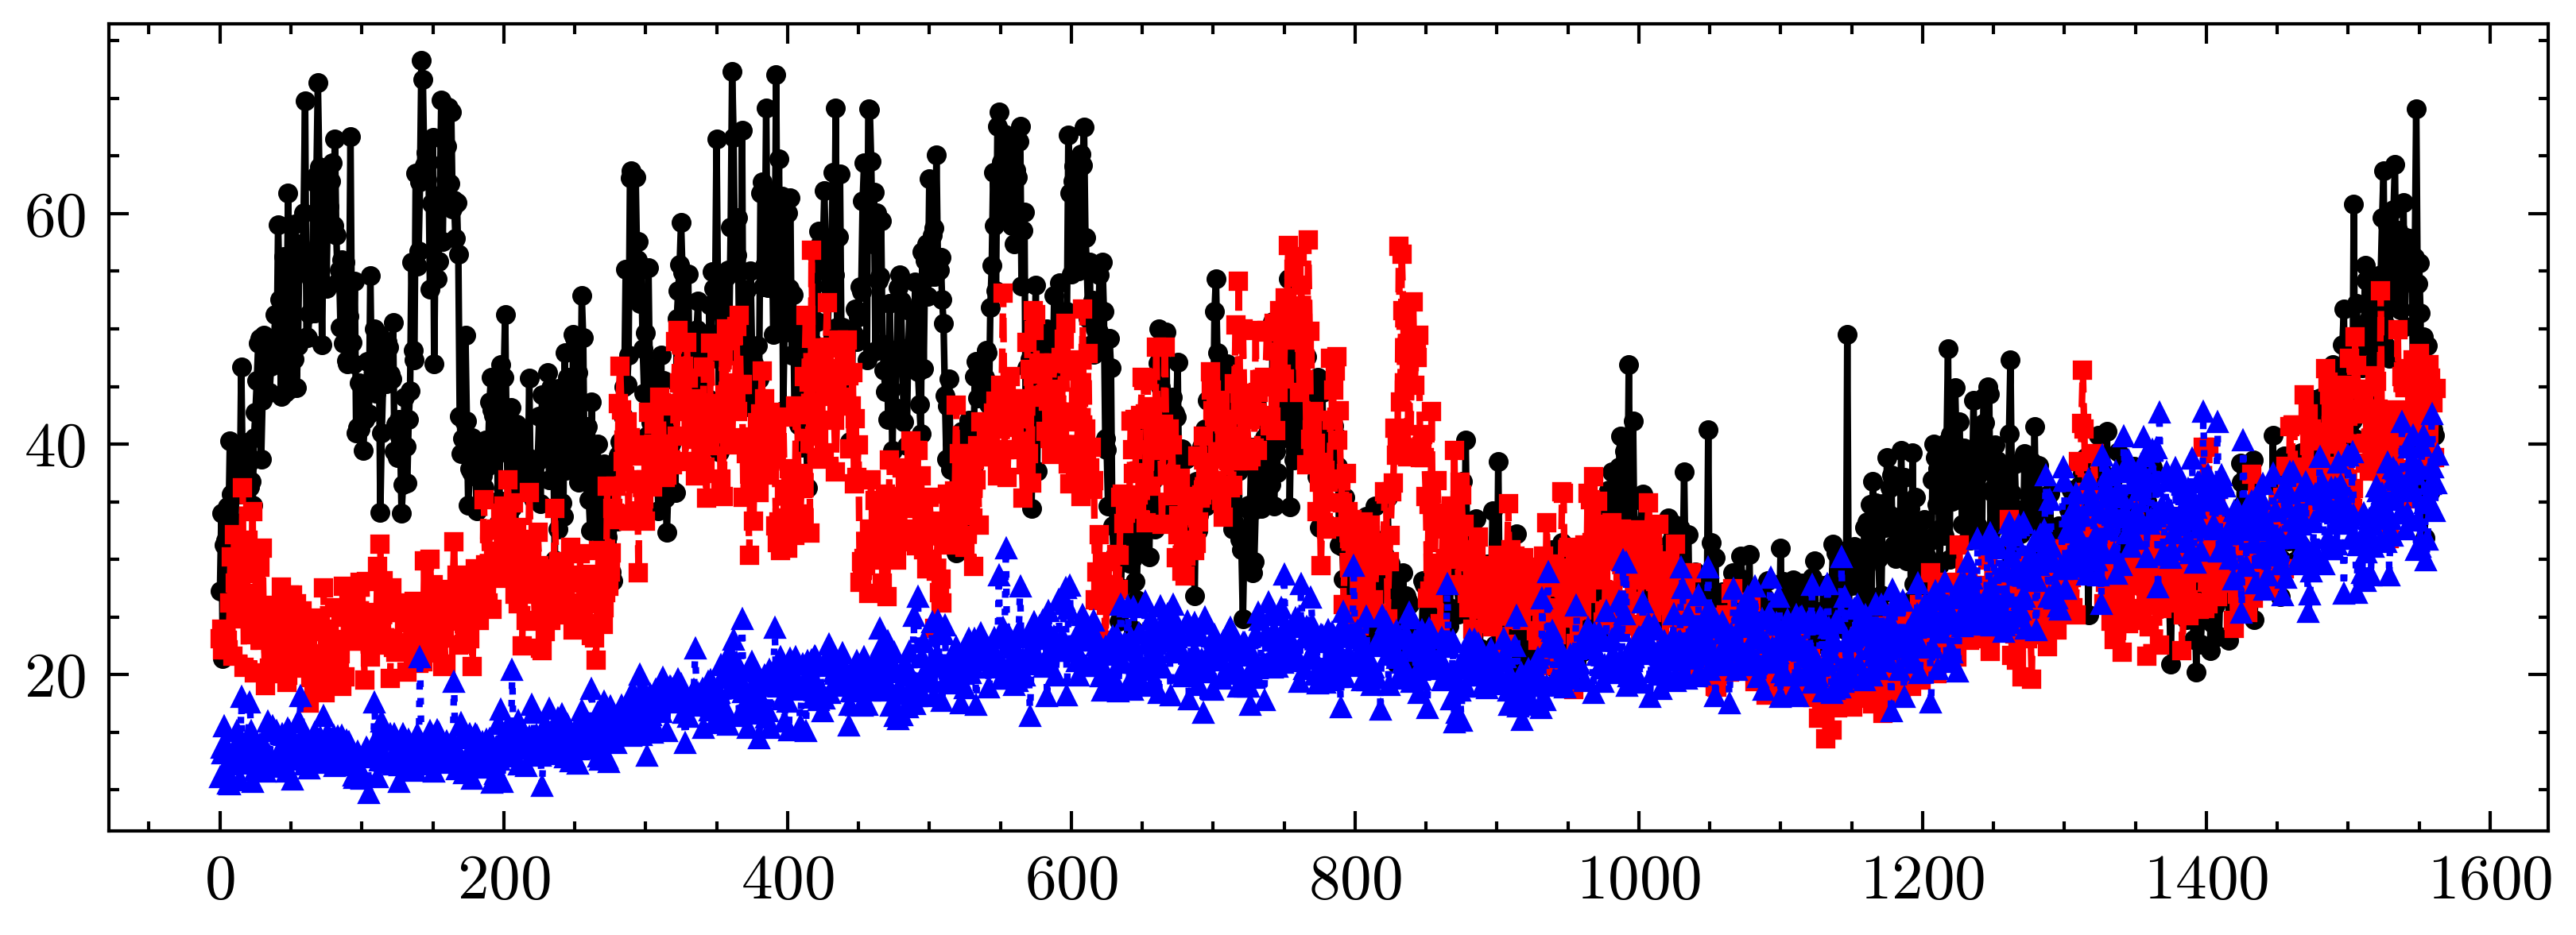

In [17]:
from utils.auger.fd import XYScanner
import sys
import importlib
from utils.binaries import *
from utils.plotting import *
from utils.auger.fd.NightSkyBackground import *
from utils.auger.fd.XYScanner import *
from pathlib import Path

BASE = Path("/cr/tempdata01/filip/CalXY_pixel_traces/")
BASE2 = Path("/cr/data02/AugerPrime/XY/2024nov/")

from scipy.optimize import curve_fit
from matplotlib.gridspec import GridSpec
from lmfit.models import GaussianModel
from scipy.stats import zscore
from tqdm import tqdm

import sys
import importlib

def get_values(params):
    return [params[p].value for p in ['amplitude', 'center', 'sigma']]

def gauss(x, A, mu, std):
    return A/np.sqrt(2*np.pi*std**2) * np.exp(-(x-mu)**2/(2*std**2))

model = GaussianModel()
nsb_fit = {}

sys.path.append('/cr/tempdata01/filip/')

run = XYScanner.Telescope(f'{SITE_SHORT}{TEL}')[-1]

start, stop, flag = np.loadtxt(BASE / f"pulseTiming_{run.get_id('XY')}.txt", usecols=[1, 2, -1], unpack=True, dtype=int)

start = start[flag == -1]
pulse_start = np.min(start) - 10

nsb_var, var_var, chisqr = [], [], []
for pixel in [220, 210, 199]:

    # if run.telescope == 'LL1' and pixel > 352:
    #     nsb_var.append(np.nan)
    #     chisqr.append(np.nan)
    #     continue
    # elif run.telescope == 'LL6' and pixel < 177:
    #     nsb_var.append(np.nan)
    #     chisqr.append(np.nan)
    #     continue             

    traces = np.loadtxt(BASE / f"dumpedTraces_{run.get_id('XY')}_pixel{pixel}.txt")[flag == -1]
    vars = np.var(traces[:, :pulse_start], axis=1)

    vars = vars[zscore(vars) < 3]

    xmin, xmax = int(np.min(vars)), int(np.max(vars))
    n, bins = np.histogram(vars, bins=xmax-xmin, range=(xmin, xmax))

    params = model.make_params(center=0.5 * (bins[1:] + bins[:-1])[np.argmax(n)],
                            amplitude = np.max(n), sigma=5)
    result = model.fit(n, params, x=0.5 * (bins[1:] + bins[:-1]))

    nsb_var.append(result.params['center'].value)
    var_var.append(result.params['sigma'].value)
    chisqr.append(result.chisqr)

    plt.plot(range(len(vars)), vars)      # yuck


In [ ]:
import mysql.connector
from getpass import getpass

def get_data(start, stop, pix):

    run_reqs = [
        f"Time between '{start}' and '{stop}'",
        f"TelescopeId = {TEL}",
    ]

    cursor.execute(f"select BGSampleTabId, Time from BGSampleTab where {' and '.join(run_reqs)};")
    df_runs = pd.DataFrame(cursor.fetchall(), columns=["BGSampleTabId", "Time"])

    if not len(df_runs): return []

    else:
        pixel_reqs = [
            f"BGSampleTabId in ({','.join(df_runs['BGSampleTabId'].astype(str))})",
            f"PixelId = {pix}",
        ]

        pixel_cols = ["BGSampleTabId", "PixelId", "Variance"]
        cursor.execute(f"select {','.join(pixel_cols)} from BGPixelTab where {' and '.join(pixel_reqs)}")
        df = pd.DataFrame(cursor.fetchall(), columns=pixel_cols)
        df = df.merge(df_runs[["BGSampleTabId", "Time"]], on='BGSampleTabId', how='left')

        f = tools.kd1d_estimate(df["Variance"], bandwidth=10)
        X = np.geomspace(1e3, 3e5, int(1e4))
        coarse_baseline = X[np.argmax(f(X))]
        data_baseline = df[df["Variance"] < 1.5 * coarse_baseline]

        data = df[df["Variance"] >= 1.5 * coarse_baseline]
        data['baseline'] = data_baseline["Variance"].median()
        data['nsb'] = (data['Variance'] - data['baseline']) / 1e3
        
        return data

In [19]:
from datetime import datetime, timedelta

all_pixel_data = []
for pix in [220, 210, 199]:

    all_pixel_data.append(get_data("2024-11-18", "2024-12-07", pix))

start = datetime(2010, 1, 1)
xmax, xmin = datetime(2024, 12, 7), datetime(2024, 11, 18)
X = np.linspace((xmin - start).days, 
                (xmax - start).days,
                10000)

to_datetime = lambda x: [start + timedelta(days=xx) for xx in x]

/tmp/ipykernel_2529151/1430891371.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['baseline'] = data_baseline["Variance"].median()
/tmp/ipykernel_2529151/1430891371.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['nsb'] = (data['Variance'] - data['baseline']) / 1e3
/tmp/ipykernel_2529151/1430891371.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation

In [20]:
all_pixel_data

[       BGSampleTabId  PixelId  Variance                Time  baseline     nsb
 216         22067136      220     60941 2024-11-22 03:12:35    3133.0  57.808
 217         22067142      220     59024 2024-11-22 03:13:05    3133.0  55.891
 218         22067148      220     55520 2024-11-22 03:13:35    3133.0  52.387
 219         22067154      220     51456 2024-11-22 03:14:05    3133.0  48.323
 220         22067160      220     46562 2024-11-22 03:14:35    3133.0  43.429
 ...              ...      ...       ...                 ...       ...     ...
 11604       22135307      220     34643 2024-12-06 07:26:56    3133.0  31.510
 11605       22135313      220     35018 2024-12-06 07:27:26    3133.0  31.885
 11606       22135319      220     35039 2024-12-06 07:27:56    3133.0  31.906
 11607       22135325      220     35411 2024-12-06 07:28:26    3133.0  32.278
 11608       22135331      220      8366 2024-12-06 07:28:56    3133.0   5.233
 
 [8895 rows x 6 columns],
        BGSampleTabId  P

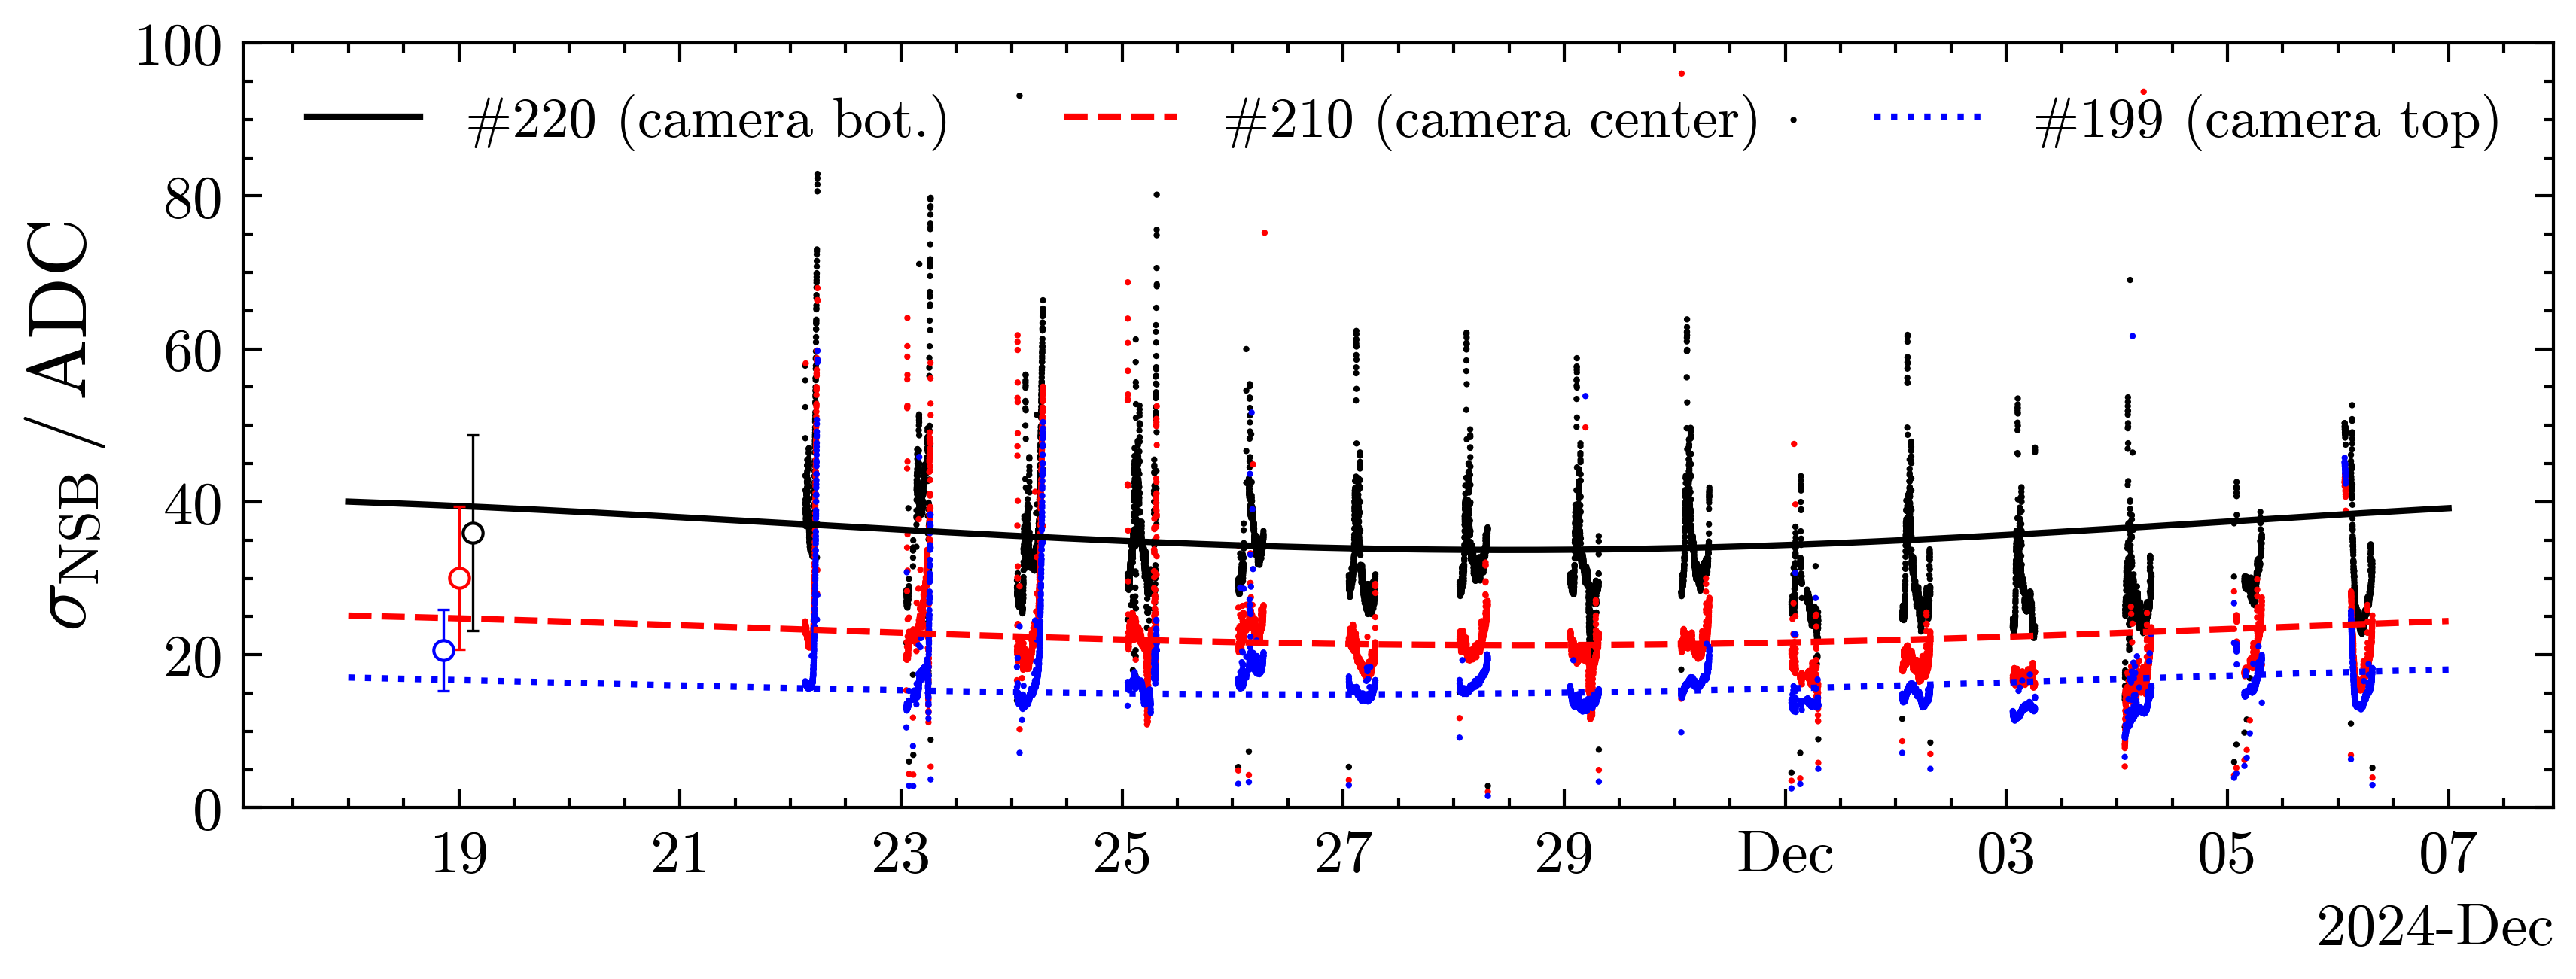

In [30]:
for pix, label, pixel_data, r, nsb, var in zip([220, 210, 199], 
                      ['#220 (camera bot.)', '#210 (camera center)', '#199 (camera top)'],
                      all_pixel_data, ['k', 'r', 'b'], nsb_var, var_var):

    pixel = CO4.get_pixel(pix)
    model = pixel.get_model(rel_height=0.1, n_peaks=7, distance=20)

    plt.scatter(pixel_data['Time'], pixel_data['nsb'], s=1, ec='none', c=r)
    plt.scatter(datetime(2024, 11, 19) + timedelta((pix-210)/80), nsb, ec=r, fc='w', s=10, lw=0.5, zorder=10)
    plt.errorbar(datetime(2024, 11, 19) + timedelta((pix-210)/80), nsb, yerr=var, c=r, ls='none', marker='none', elinewidth=0.4, capsize=1, capthick=0.4)
    plt.plot(to_datetime(X), model(X), marker='none', label=label, c=r)

plt.legend(ncol=3, fontsize=9)
plt.ylim(0, 100)
plt.ylabel("$\sigma_\mathrm{NSB}\,/\,\mathrm{ADC}$")
plot.apply_datetime_format(plt.gca())
plot.save(plt.gcf(), f"nsb_thesis_plots/model_benchmark_{SITE}_{TEL}")

In [22]:
pixel_data

,BGSampleTabId,PixelId,Variance,Time,baseline,nsb
216,22067136,199,18724,2024-11-22 03:12:35,2287.0,16.437
217,22067142,199,18620,2024-11-22 03:13:05,2287.0,16.333
218,22067148,199,18824,2024-11-22 03:13:35,2287.0,16.537
219,22067154,199,18571,2024-11-22 03:14:05,2287.0,16.284
220,22067160,199,18439,2024-11-22 03:14:35,2287.0,16.152
...,...,...,...,...,...,...
11604,22135307,199,20510,2024-12-06 07:26:56,2287.0,18.223
11605,22135313,199,20298,2024-12-06 07:27:26,2287.0,18.011
11606,22135319,199,20405,2024-12-06 07:27:56,2287.0,18.118
11607,22135325,199,20545,2024-12-06 07:28:26,2287.0,18.258
